# **LSTMs FOR PREDICTING BTC PRICES** 

## **1. Introduction**

In this lesson, we will develop our first LSTM neural network using high-frequency data on Bitcoin prices. This way, we will also experiment with relatively high frequency data (we will have hourly observations) and how to deal with some of the issues this type of data imposes. Moreover, we will work with a reduced dataset during the lesson to minimize computational time, but you will have the complete dataset available to play around with and see how different models perform for other chunks of data.

\
At this point, it is likely that all of you are quite familiar with Bitcoin (BTC) prices and how they are expressed. Since BTC is a currency after all, its prices are most commonly expressed in dollar terms per unit of BTC currency. This means that when we say BTC is at 20,000, we mean 1 unit of BTC could be exchanged for 20,000 USD. This is somewhat obvious but sometimes important to keep in mind, since the different risks affecting the price of BTC can stem from different sources that affect the 'pair' BTC-USD.

\
The specific data we are going to work with in this lesson comes from Kraken.com (https://www.kraken.com). This is essentially a crypto-asset exchange that also makes available transaction data on different "coins" and NFTs. **Please, by no means should you interpret this as a recommendation to invest in BTC, crypto, or NFTs.** We are just going to leverage this data to have a little fun while investigating whether LSTM do a decent enough job in predicting high-frequency BTC prices.

\
So, let's get to it!

## **2. Data**

As usual, let's start by importing our data and cleaning if necessary:

\
First, the libraries that we will need,

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

2025-05-14 12:53:17.428018: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-14 12:53:17.498641: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-14 12:53:19.344432: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Then, let's set up our interface to import the data:

In [2]:
drivepath = "Kraken_BTCUSD_60_3Q2022.csv"

In [3]:
df = pd.read_csv(drivepath)

# Given the format of the data, we need to also
df["unix"] = pd.to_numeric(df["unix"])
df["date"] = pd.to_datetime(df["unix"], unit="s")

How does our data look?

In [4]:
df

,unix,open,high,low,close,volume,trades,date
0,1381093200,122.00000,122.00000,122.00,122.00,0.100000,1,2013-10-06 21:00:00
1,1381176000,123.61000,123.61000,123.61,123.61,0.100000,1,2013-10-07 20:00:00
2,1381197600,123.91000,123.91000,123.90,123.90,1.991600,2,2013-10-08 02:00:00
3,1381208400,124.19000,124.19000,124.18,124.18,2.000000,2,2013-10-08 05:00:00
4,1381309200,124.01687,124.01687,123.84,123.84,2.823000,3,2013-10-09 09:00:00
...,...,...,...,...,...,...,...,...
67886,1664564400,19673.10000,19762.90000,19482.80,19497.20,290.023381,1947,2022-09-30 19:00:00
67887,1664568000,19491.00000,19535.70000,19351.20,19420.40,759.074836,1648,2022-09-30 20:00:00
67888,1664571600,19423.60000,19423.60000,19281.00,19360.40,564.894247,1245,2022-09-30 21:00:00
67889,1664575200,19354.20000,19399.90000,19232.60,19387.10,90.626135,1978,2022-09-30 22:00:00


As you can see, there is a lot of information in our hourly data on BTC prices. We have data on open, high, low, and close prices for each hour between October 2013 and September 2022. Since this data is somewhat special compared to our 'usual' stock and index prices, it deserves a little more exploration before jumping to the prediction problem using LSTMs.

## **3. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is a useful process in these cases in which we are not too familiar with the data we are dealing with. It basically consists of exploring the data, specially via visualization, which simplifies the task of learning how the data behaves. This will be relevant later on to decide the kind of scaling we need, to give more or less importance to the presence of outliers, etc.


We will start by simply looking at the hourly closing prices throughout the whole period:

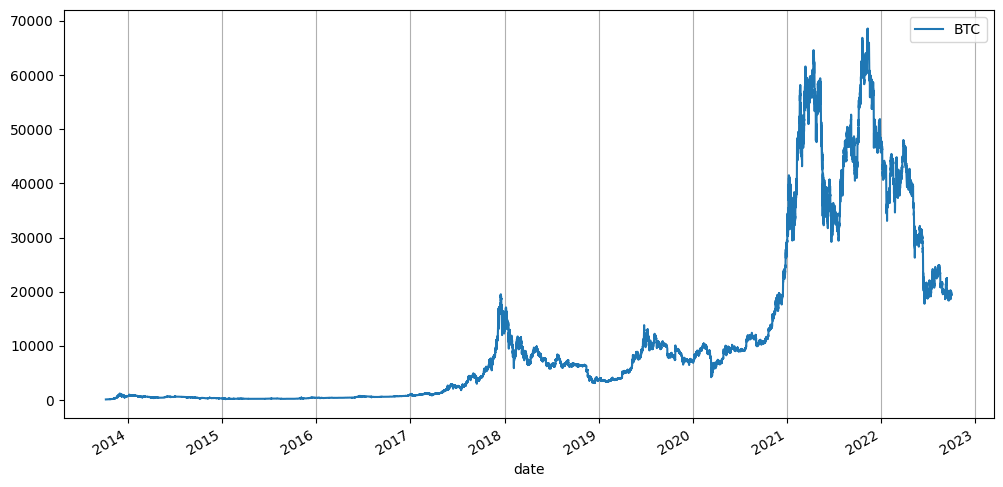

In [5]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="date", y="close", label="BTC", ax=ax).grid(axis="x")

From the previous graph, we observe a clear upward trend in the last few years that, nonetheless, has stopped in more recent years. BTC prices are now in the neighborhood of 20,000 USD, far from its maximum of nearly 70,000 USD by the final months of 2022.

\
Has this increase in prices been accompanied by similar increases in volume?

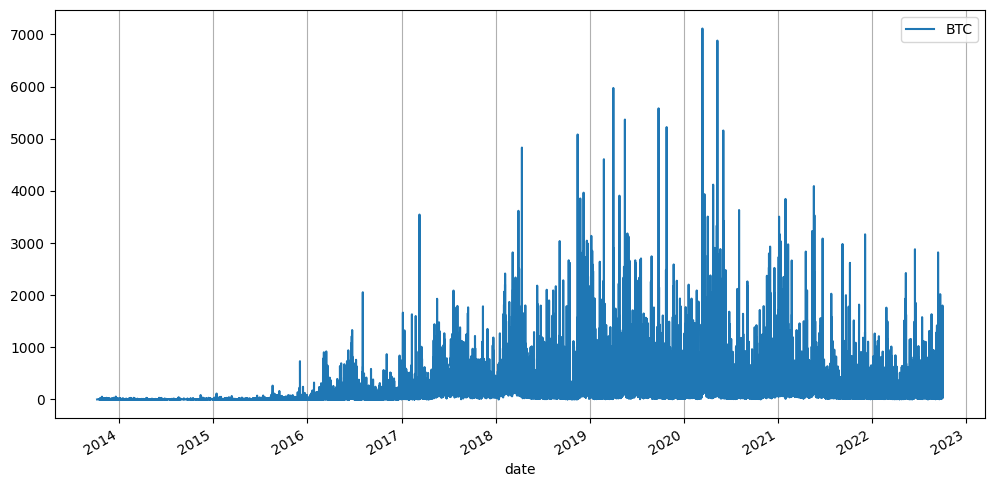

In [6]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="date", y="volume", label="BTC", ax=ax).grid(axis="x")

What about the distribution of hourly returns?

<Axes: >

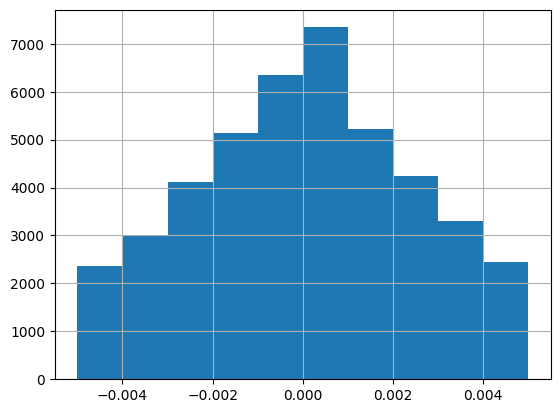

In [7]:
df["Ret"] = df["close"].pct_change()
df["Ret"].hist(range=[-0.005, 0.005])

<Axes: >

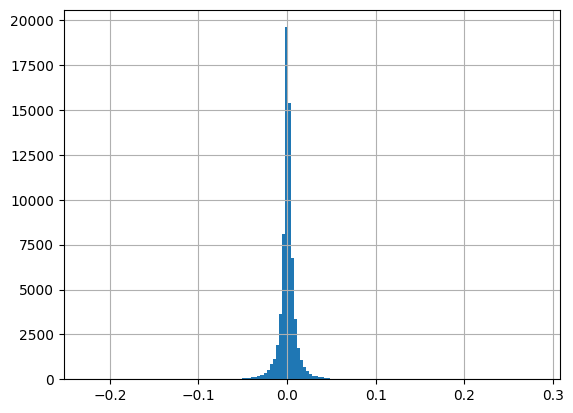

In [8]:
df["Ret"].hist(bins=150)

Well, indeed, hourly returns seem pretty centered around zero, resembling a normally distributed variable. Is this the case though?

In [9]:
df["Ret"].describe()

count    67890.000000
mean         0.000140
std          0.011395
min         -0.226804
25%         -0.003045
50%          0.000016
75%          0.003381
max          0.282090
Name: Ret, dtype: float64

Well, so far, we have looked at the raw data (i.e., in hourly frequency). But maybe it is also interesting to see how the data behaves when we aggregate it at other frequencies. Furthermore, is there any kind of stationarity in the data? It may be the case that BTC prices always climb (or fall) at specific hours or during specific days of the week. This can be especially relevant for prediction tasks that rely on sequences or memory:

In [10]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["week"] = df["date"].dt.isocalendar().week
df["weekday"] = df["date"].dt.weekday
df["hour"] = df["date"].dt.hour

Let's look at things by hour of the day. We could spend a long time on all these tests, but for the sake of time, we will simply look at average returns during specific hours. Feel free to play with this data by yourselves!

<Axes: xlabel='hour'>

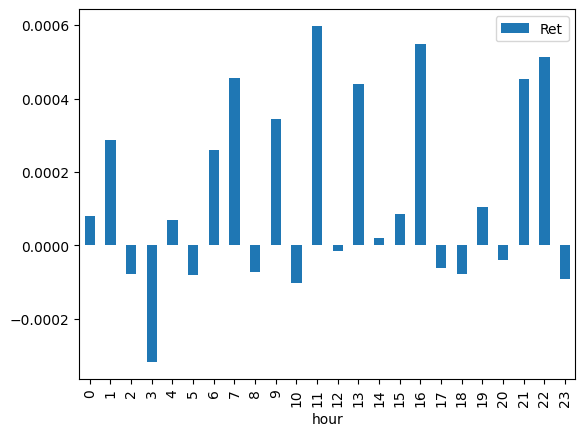

In [11]:
df_hour = df[["Ret", "hour"]]
df_hour.groupby(by="hour").mean().plot(kind="bar")

Well, it seems that, on average, BTC prices usually tend to go up at 21h and 22h, while they usually fall by 3am. Note that these are very simple observations and have nothing to do with any kind of causal interpretation you can think of.

Let's see what happens by day of the week:

<Axes: xlabel='weekday'>

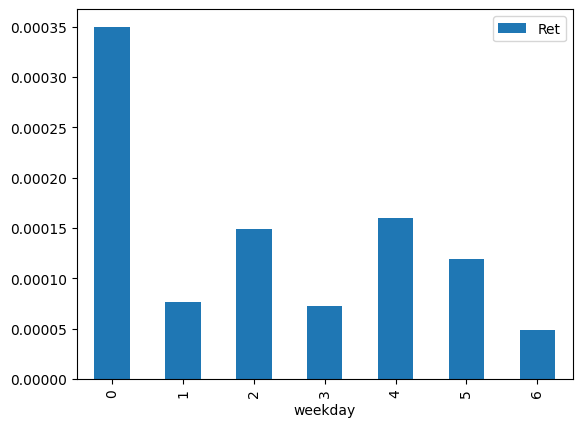

In [12]:
df_weekday = df[["Ret", "weekday"]]
df_weekday.groupby(by="weekday").mean().plot(kind="bar")

Similar observations can be drawn from this information. However, remember that no causal claim can be made from this!

What about month of the year?

<Axes: xlabel='month'>

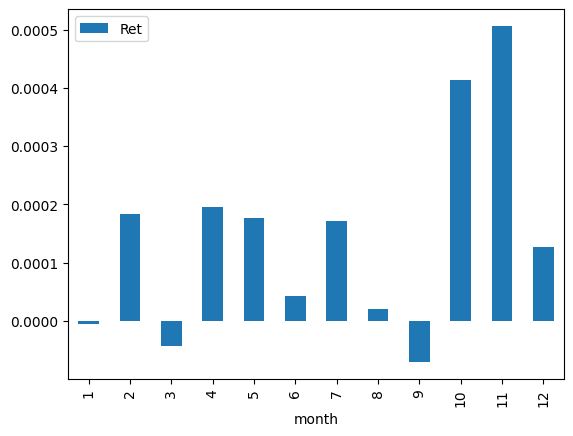

In [13]:
df_month = df[["Ret", "month"]]
df_month.groupby(by="month").mean().plot(kind="bar")

Once again, we can observe that, in the period analyzed, BTC returns were especially positive during October and November. But one more time, no causal inference can be made from this data.

\
Lastly, let's see how hourly returns evolved through time:

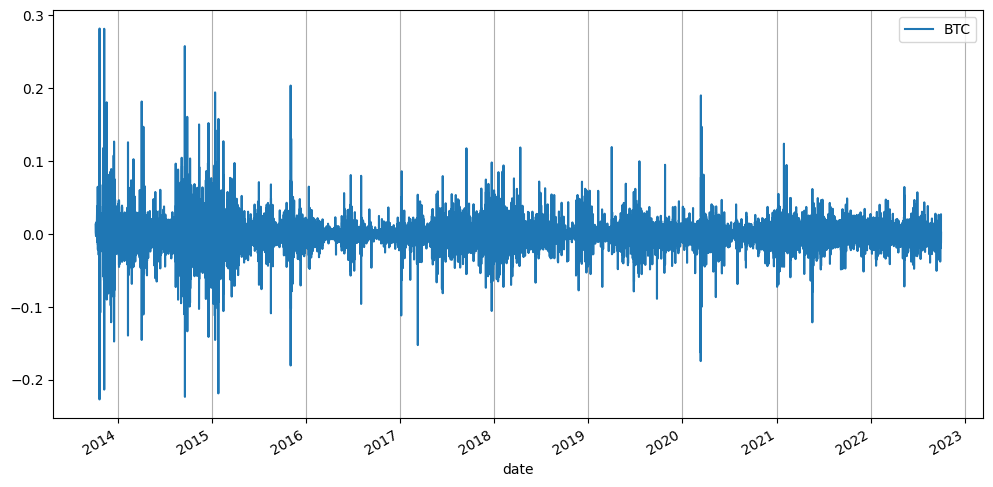

In [14]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="date", y="Ret", label="BTC", ax=ax).grid(axis="x")

Here, we can see how returns have become less volatile with time. This makes a lot of sense, as the incorporation of major institutional investors to the BTC market propitiated an increase in market liquidity, leading to lower price impact of trades and fewer price swings. But again, no causal interpretation of the results so far.

\
So, now that we know a little bit more about how BTC prices fluctuate and the main 'stylized facts' of the data, let's see if a Neural Network based on LSTM can do a good job in predicting future prices once trained.

## **4. Forecasting**

Let's build our LSTM-based prediction model!

The first thing that we are going to do with this large dataset is to keep only the variables we will be using in our model, selecting a chunk of the data to reduce computational time, and replacing missing values:

In [15]:
df = df[["date", "close", "volume", "trades"]]
df["Ret"] = df["close"].pct_change()
df["year"] = df["date"].dt.year
del df["close"]
df = df.loc[(df["year"] >= 2021)]  # To reduce the computational time

/tmp/ipykernel_27/800848297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ret"] = df["close"].pct_change()
/tmp/ipykernel_27/800848297.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["date"].dt.year


Given the way Kraken data is structured, we may have, especially in the "old days" a bunch of missing values in returns, volume, or trades. This is simply because when the market was not so liquid (or at very specific instances), there may not be a trade happening, and therefore, we won't have information for that variable-hour. For that reason, we are going to replace returns, volume, and trades with zeroes. 

Please note that this is not a usual good practice with financial data unless, as in this case, we do have an explanation for the missing data. <span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [16]:
df["Ret"] = df["Ret"].fillna(0)
df["volume"] = df["volume"].fillna(0)
df["trades"] = df["trades"].fillna(0)

So, this is finally how our data looks:

In [17]:
df.head()

,date,volume,trades,Ret,year
52585,2021-01-01 00:00:00,272.113148,2071,0.003792,2021
52586,2021-01-01 01:00:00,718.037476,3675,0.013203,2021
52587,2021-01-01 02:00:00,274.612863,1433,-0.007229,2021
52588,2021-01-01 03:00:00,86.226981,750,0.003492,2021
52589,2021-01-01 04:00:00,330.509906,1494,-0.002590,2021


We are going to work with these variables and construct a number of different predictors, in a similar fashion to what we have done in previous notebooks of the course.

\
Specifically, we will compute the 1-hour, 10-hour, 50-hour, and 25-hour cumulative return. The latter (25-hour) is the one we will try to predict using an LSTM model:

In [18]:
df = df.reindex(
    columns=[
        "date",
        "Ret",
        "volume",
        "trades",
        "year",
        "month",
        "day",
        "week",
        "weekday",
        "hour",
    ]
)
df = df[["date", "Ret"]]

df["Ret_10"] = df["Ret"].rolling(10).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret_50"] = df["Ret"].rolling(50).apply(lambda x: np.prod(1 + x / 100) - 1)

df["Ret_25"] = df["Ret"].rolling(25).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret25"] = df["Ret_25"].shift(-25)
del df["Ret_25"]
df = df.dropna()

This is how our working data will look:

In [19]:
df.head()

,date,Ret,Ret_10,Ret_50,Ret25
52634,2021-01-03 01:00:00,0.003812,0.000300,0.001236,0.000294
52635,2021-01-03 02:00:00,0.004669,0.000103,0.001244,0.000270
52636,2021-01-03 03:00:00,-0.004577,-0.000065,0.001066,0.000233
52637,2021-01-03 04:00:00,0.019479,0.000120,0.001334,-0.000088
52638,2021-01-03 05:00:00,0.014644,0.000235,0.001445,-0.000118


With this data, we will use the 1-hour, 10-hour, and 50-hour cumulative returns of BTC to predict the 25-hour ahead return. Thus, we define our input (X) and output (y) matrices as:

In [20]:
Xdf, ydf = df.iloc[:, 1:-1], df.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")

As usual, we will need to define the validation, train, and test samples. Also, the window (sequence length) we will use in our LSTM:

In [21]:
val_split = 0.2
train_split = 0.625
train_size = int(len(df) * train_split)
val_size = int(train_size * val_split)
test_size = int(len(df) - train_size)

window_size = 30

ts = test_size
split_time = len(df) - ts
test_time = df.iloc[split_time + window_size :, 0:1].values


y_train_set = y[:split_time]
y_test_set = y[split_time:]

X_train_set = X[:split_time]
X_test_set = X[split_time:]

n_features = X_train_set.shape[1]

And scale the different variables under the usual MinMaxScaler:

In [22]:
scaler_input = MinMaxScaler(feature_range=(-1, 1))
scaler_input.fit(X_train_set)
X_train_set_scaled = scaler_input.transform(X_train_set)
X_test_set_scaled = scaler_input.transform(X_test_set)

mean_ret = np.mean(y_train_set)

scaler_output = MinMaxScaler(feature_range=(-1, 1))
y_train_set = y_train_set.values.reshape(len(y_train_set), 1)
y_test_set = y_test_set.values.reshape(len(y_test_set), 1)
scaler_output.fit(y_train_set)
y_train_set_scaled = scaler_output.transform(y_train_set)

Once we have all this, we can finally split the data we will use for training and test:

In [23]:
training_time = df.iloc[:split_time, 0:1].values

X_train = []
y_train = []

for i in range(window_size, y_train_set_scaled.shape[0]):
    X_train.append(X_train_set_scaled[i - window_size : i, :])
    y_train.append(y_train_set_scaled[i])

X_train, y_train = np.array(X_train), np.array(y_train)

print("Shape of training data", X_train.shape, y_train.shape)

X_test = []
y_test = y_test_set

for i in range(window_size, y_test_set.shape[0]):
    X_test.append(X_test_set_scaled[i - window_size : i, :])

X_test, y_test = np.array(X_test), np.array(y_test)

print("Shape of test data", X_test.shape, y_test.shape)

Shape of training data (9490, 30, 3) (9490, 1)
Shape of test data (5682, 30, 3) (5712, 1)


Now it is time to define our LSTM model!

- **The LSTM model:**

*Note that we also set a seed for Dropout layers (=1234) to replicate results. Feel free to play around with this!*

In [24]:
SEED = 1234

units_lstm = 50
n_dropout = 0.2
act_fun = "relu"

from keras import Sequential
from keras.callbacks import EarlyStopping

model = Sequential()

model.add(
    LSTM(
        units=units_lstm,
        return_sequences=True,
        activation="tanh",
        input_shape=(X_train.shape[1], n_features),
    )
)
model.add(LSTM(units=units_lstm, return_sequences=True, activation="tanh"))
model.add(Dropout(n_dropout, seed=SEED))


model.add(LSTM(units=units_lstm, return_sequences=True, activation="tanh"))
model.add(Dropout(n_dropout, seed=SEED))


model.add(LSTM(units=units_lstm, return_sequences=False, activation="tanh"))
model.add(Dropout(n_dropout, seed=SEED))

model.add(Dense(units=20, activation=act_fun))
model.add(Dropout(n_dropout, seed=SEED))

model.add(Dense(units=10, activation=act_fun))
model.add(Dropout(n_dropout, seed=SEED))

model.add(Dense(1))

/usr/local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


How does this model look like? It is basically a series of LSTM layers (with Dropout after some of them) followed by 3 final dense layers:

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,641 (283.75 KB)

 Trainable params: 72,641 (283.75 KB)

 Non-trainable params: 0 (0.00 B)

**A quick note on the model parameters:**

Where does the 20,200 parameters in lstm_1 come from? Well, in order to define the number of parameters in an LSTM layer, we can use the knowledge that we have already regarding how many parameters (i.e., weights) are trained in each of the equations of the model. Given that there are 4 equations (the usual one plus the extra 3 of the different gates in LSTM layers):

$$
\begin{equation*}
 \# \ of \ parameters \  = 4 \times \left( \left( Hidden \ Units + Input \ size \right) \times Hidden \ Units + Hidden \ Units \right)
\end{equation*}
$$

Applying the previous to lstm_1:


$$
\begin{equation*}
 4 \times \left( \left( 50 + 50  \right) \times 50 + 50 \right) = 20,200
\end{equation*}
$$

\
Now, we only need to define the usual final features (learning rate, loss function, early stopping criteria, batch size, ...) and train the model:

In [26]:
hp_lr = 1e-4
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error"
)

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=0, patience=5, restore_best_weights=True
)

# fit the models
model.fit(
    X_train,
    y_train,
    validation_split=val_split,
    epochs=50,
    batch_size=64,
    verbose=2,
    callbacks=[es],
)

Epoch 1/50
119/119 - 9s - 74ms/step - loss: 0.1445 - val_loss: 0.1014
Epoch 2/50
119/119 - 5s - 39ms/step - loss: 0.1365 - val_loss: 0.1010
Epoch 3/50
119/119 - 5s - 44ms/step - loss: 0.1356 - val_loss: 0.1004
Epoch 4/50
119/119 - 5s - 43ms/step - loss: 0.1340 - val_loss: 0.1011
Epoch 5/50
119/119 - 5s - 43ms/step - loss: 0.1345 - val_loss: 0.1007
Epoch 6/50
119/119 - 5s - 43ms/step - loss: 0.1333 - val_loss: 0.1014
Epoch 7/50
119/119 - 5s - 43ms/step - loss: 0.1331 - val_loss: 0.1029
Epoch 8/50
119/119 - 5s - 43ms/step - loss: 0.1326 - val_loss: 0.1020


Let's see how this performs out of sample using the standard out-of-sample R-squared measured ($R_{OOS}$) that we have introduced in previous notebooks. 

In [27]:
prediction = model.predict(X_test)
prediction = scaler_output.inverse_transform(prediction)
prediction = prediction.flatten()

values = np.array(y_test[window_size:])
values = values.flatten()


def R2_campbell(y_true, y_predicted, mean_ret):
    y_predicted = y_predicted.reshape((-1,))
    sse = sum((y_true - y_predicted) ** 2)
    tse = sum((y_true - mean_ret) ** 2)
    r2_score = 1 - (sse / tse)

    return r2_score


R2_Campbell = R2_campbell(values, prediction, mean_ret)
print("Out-of-sample R-squared:", R2_Campbell)

#
df_predictions = pd.DataFrame(
    {"Date": test_time.flatten(), "Pred LSTM": prediction, "values": values}
)
df_predictions.head()

178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Out-of-sample R-squared: -0.0005813956678202281


,Date,Pred LSTM,values
0,2022-02-05 05:00:00,-0.000011,-0.000017
1,2022-02-05 06:00:00,-0.000011,0.000035
2,2022-02-05 07:00:00,-0.000011,0.000060
3,2022-02-05 08:00:00,-0.000012,0.000046
4,2022-02-05 09:00:00,-0.000012,0.000012


As you can see, the performance out of sample of the model doesn't look so bad. Also, remember that we have used a shortened version of the dataset to reduce computational time. We leave it to you to play with the longer version (careful with computational times!) and try to squeeze the prediction power of the model.

## **5. Backtest**

Finally, let's explore how the predictive performance of the model would have worked in the test period if we traded based on the output of the LSTM model!

We will basically trade long (buy BTC) whenever the 25-day prediction is positive and short (sell BTC) when negative.


In [ ]:
df_predictions["Positions"] = df_predictions["Pred LSTM"].apply(np.sign)
df_predictions["Strat_ret"] = (
    df_predictions["Positions"].shift(1) * df_predictions["values"]
)
df_predictions["CumRet"] = (
    df_predictions["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)
df_predictions["bhRet"] = (
    df_predictions["values"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)

Final_Return = np.prod(1 + df_predictions["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df_predictions["values"]) - 1

print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

ax = plt.gca()
df_predictions.plot(x="Date", y="bhRet", ax=ax)
df_predictions.plot(x="Date", y="CumRet", ax=ax)
plt.show()

As we can see, our strategy backtest does a pretty decent job over the buy-and-hold strategy. However, it does not deliver a huge return. As always, the usual disclaimers and caveats about backtesting apply!

- **The role of transaction costs**

A final quick note on transaction costs is necessary here. Trading in the market conveys transaction costs such as brokerage fees. Notice that we have not accounted for these costs before, most of the time because when the number of trades in the testing period is low the impact of transaction costs is minimal. However, in this specific case with hourly data, these costs may be relevant. In the future, we will see how we can incorporate these. For now, it is enough if you acknowledge that the returns obtained here may be misleading as they do not account for transaction costs.

## **6. Conclusion**

In this lesson, we have developed our first LSTM model for predicting the prices of Bitcoin. Although we have found quite decent results in terms of the predictive power of the model, as well as the backtest of the strategy, there is still a lot more to be done when implementing LSTM and other modern Recurrent Neural Networks. In the next lesson, we will take a look at bidirectional networks. See you there!